In [1]:
import numpy as np
from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import allensdk.brain_observatory.stimulus_info as stim_info
from skimage.transform import resize
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import umap
import random
from wiring_efficiency_utils import *
from map_plotting import *

/home/nicolamendini/allen_env/lib/python3.11/site-packages/allensdk/core/brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Found 18 layer-4 experiments with gratings (before filtering)
Processing layer-4 experiment 500860585...


2026-01-17 18:01:33,205 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/514408402


  Using 139 tuned cells (static_gratings)
Processing layer-4 experiment 501021421...


2026-01-17 18:01:46,874 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/516803064


  Using 88 tuned cells (static_gratings)
Processing layer-4 experiment 508356957...


...

  Using 35 tuned cells (static_gratings)
Processing layer-4 experiment 547388708...


2026-01-17 18:05:49,898 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/549317860


  Using 76 tuned cells (static_gratings)
Processing layer-4 experiment 547573479...


2026-01-17 18:06:08,450 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/549288655


  Using 95 tuned cells (static_gratings)

Successfully processed 15 layer-4 experiments


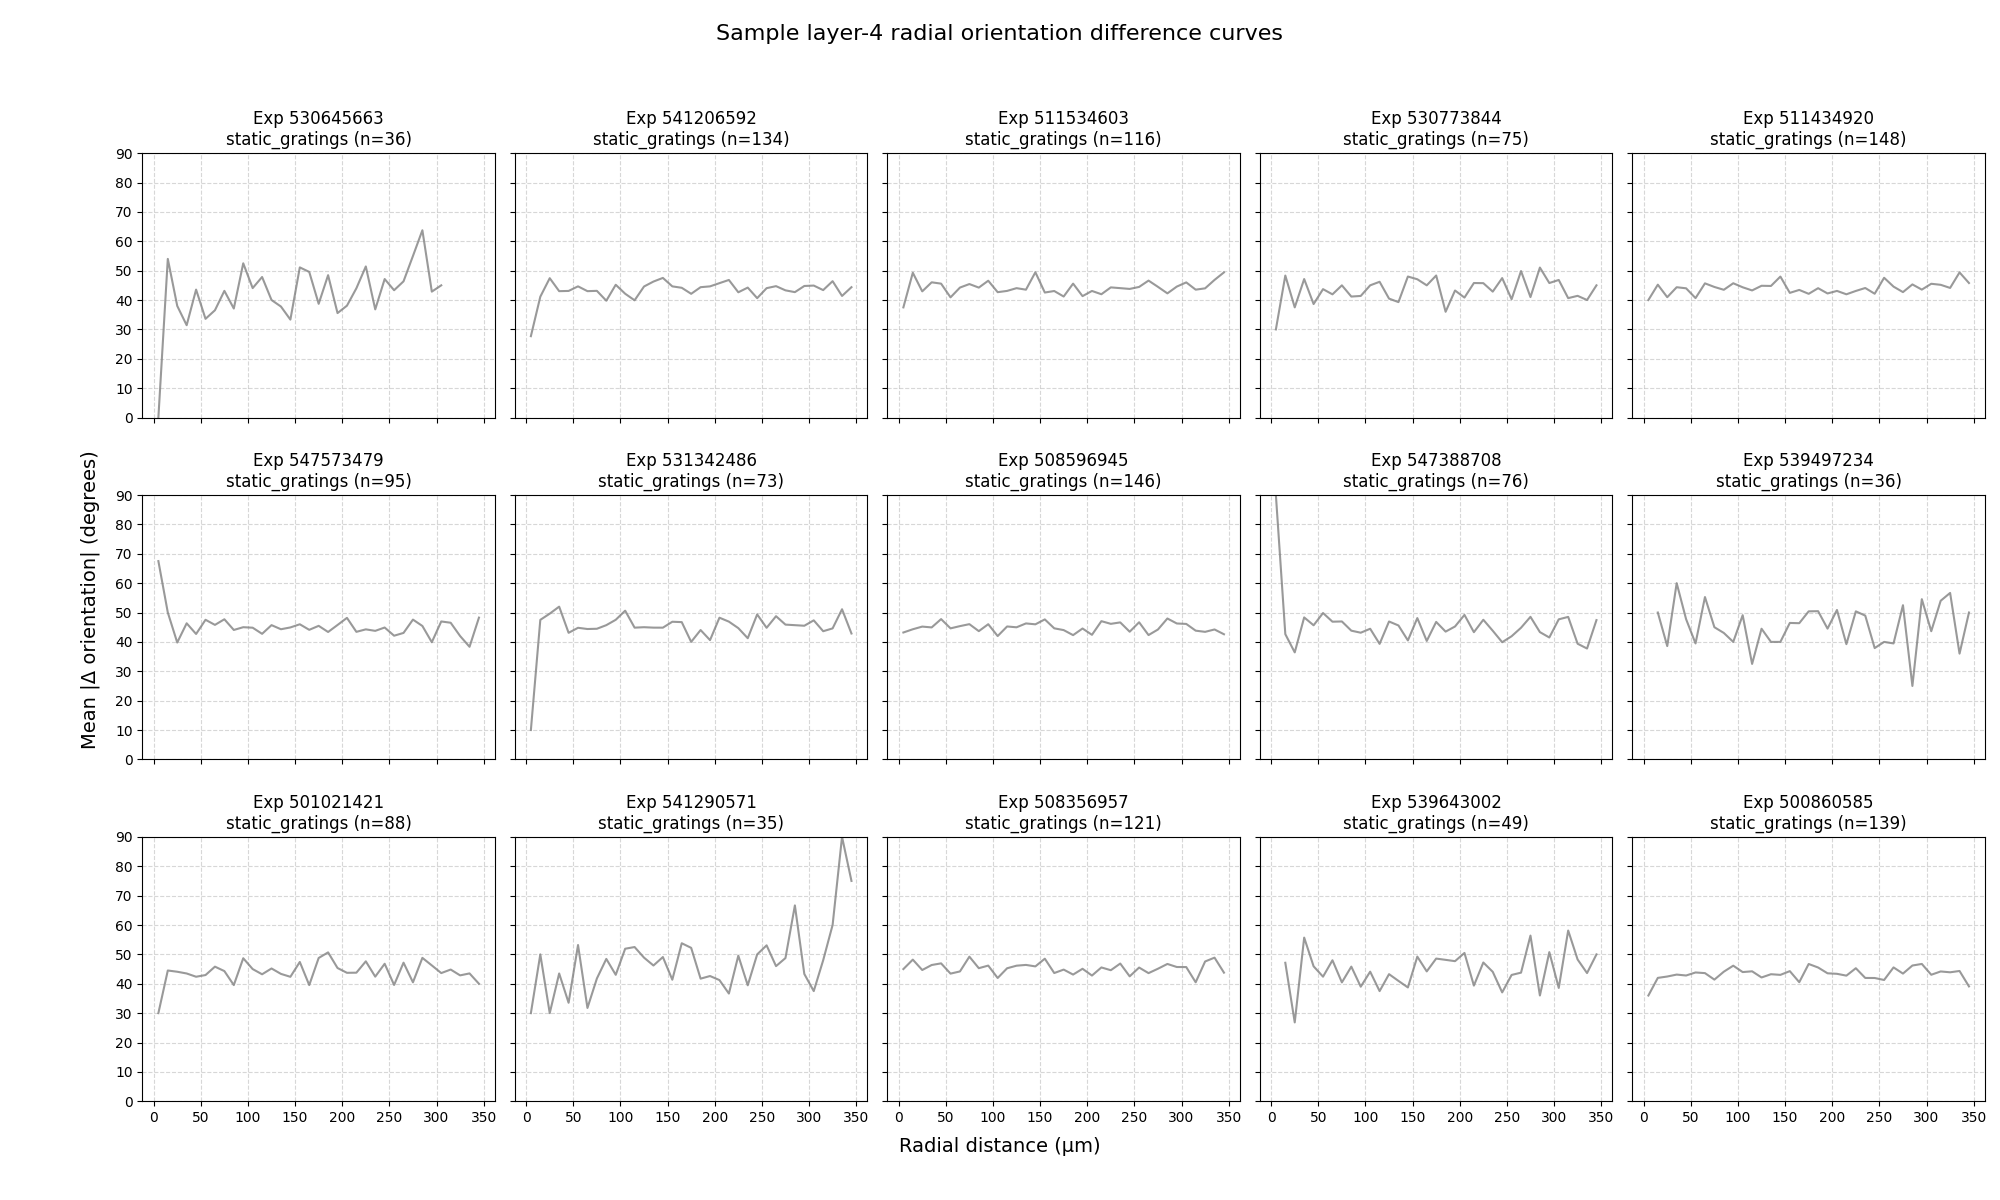

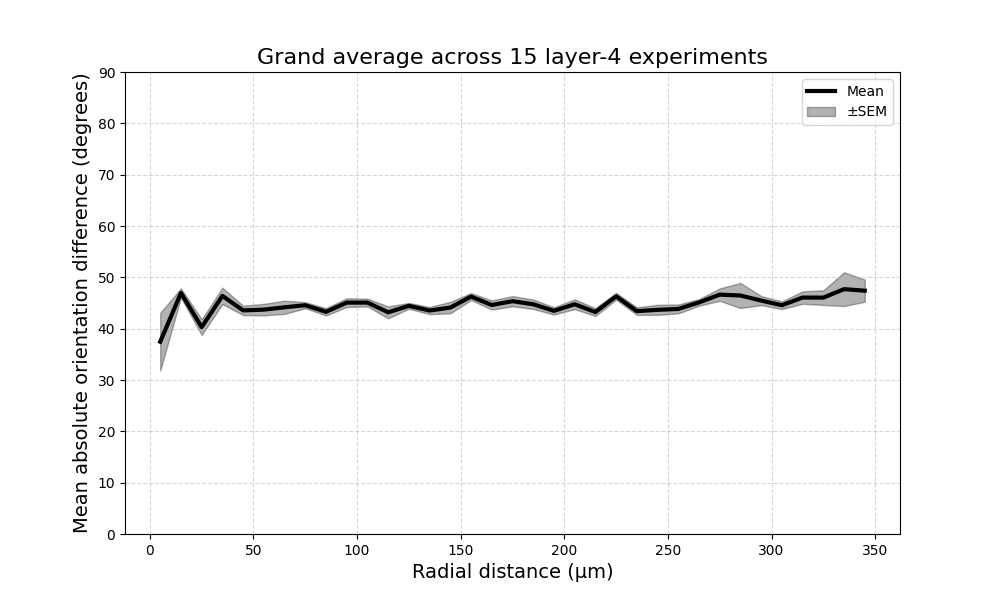

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from scipy.stats import binned_statistic
from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import random

# Update your manifest path
manifest_path = 'path/to/your/boc/manifest.json'
boc = BrainObservatoryCache(manifest_file=manifest_path)

# === Restrict to layer 4 (Scnn1a-Tg3-Cre) with gratings ===
static_exps = boc.get_ophys_experiments(
    cre_lines=['Scnn1a-Tg3-Cre'],
    stimuli=['static_gratings']
)
drifting_exps = boc.get_ophys_experiments(
    cre_lines=['Scnn1a-Tg3-Cre'],
    stimuli=['drifting_gratings']
)

# Unique experiment IDs (some sessions have both stimuli)
all_exp_ids = set(e['id'] for e in static_exps + drifting_exps)
print(f"Found {len(all_exp_ids)} layer-4 experiments with gratings (before filtering)")

# Common distance bins in microns (10 µm bins, up to 350 µm)
bin_edges = np.linspace(0, 350, 36)  # 35 bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Containers
curves = []       # list of (35,) mean |Δori| arrays
exp_info = []     # metadata

min_tuned_cells = 30  # require at least this many tuned neurons

for exp_id in sorted(all_exp_ids):
    try:
        print(f"Processing layer-4 experiment {exp_id}...")
        data_set = boc.get_ophys_experiment_data(exp_id)

        cell_ids = data_set.get_cell_specimen_ids()
        if len(cell_ids) < min_tuned_cells:
            print(f"  Skipped: too few cells ({len(cell_ids)})")
            continue

        # ROI masks → coordinates
        roi_masks = data_set.get_roi_mask_array(cell_specimen_ids=cell_ids)
        height, width = roi_masks.shape[1:]

        # Pixel size (standard ~400 µm FOV)
        pixel_size_um = 400.0 / 512.0
        if height != 512 or width != 512:
            pixel_size_um = 400.0 / ((height + width) / 2.0)

        coords_px = np.zeros((len(cell_ids), 2))
        for i, mask in enumerate(roi_masks):
            if mask.sum() > 0:
                y, x = center_of_mass(mask)
                coords_px[i] = [y, x]

        # Cell metrics
        cell_spec_raw = boc.get_cell_specimens(ids=cell_ids)
        if isinstance(cell_spec_raw, list):
            cell_spec = pd.DataFrame(cell_spec_raw)
        else:
            cell_spec = cell_spec_raw

        id_col = 'cell_specimen_id' if 'cell_specimen_id' in cell_spec.columns else 'id'

        # Prefer drifting gratings tuning if available
        if 'pref_ori_dg' in cell_spec.columns:
            tuned_count = cell_spec['pref_ori_dg'].notna().sum()
            if tuned_count >= min_tuned_cells:
                pref_col = 'pref_ori_dg'
                stim_type = 'drifting_gratings'
            else:
                pref_col = None
        else:
            pref_col = None

        if pref_col is None and 'pref_ori_sg' in cell_spec.columns:
            tuned_count = cell_spec['pref_ori_sg'].notna().sum()
            if tuned_count >= min_tuned_cells:
                pref_col = 'pref_ori_sg'
                stim_type = 'static_gratings'
            else:
                pref_col = None

        if pref_col is None:
            print(f"  Skipped: insufficient tuned cells")
            continue

        pref_dict = dict(zip(cell_spec[id_col], cell_spec[pref_col]))
        pref_ori = np.array([pref_dict.get(cid, np.nan) for cid in cell_ids])

        # Keep tuned neurons only
        valid = ~np.isnan(pref_ori)
        coords_um = coords_px[valid] * pixel_size_um
        pref_ori = pref_ori[valid]

        n_cells = len(pref_ori)
        print(f"  Using {n_cells} tuned cells ({stim_type})")

        # Pairwise distances and Δori
        dy = coords_um[:, 0][:, None] - coords_um[:, 0][None, :]
        dx = coords_um[:, 1][:, None] - coords_um[:, 1][None, :]
        dist_matrix = np.sqrt(dy**2 + dx**2)

        delta_ori = np.abs(pref_ori[:, None] - pref_ori[None, :])
        delta_ori = np.minimum(delta_ori, 180 - delta_ori)  # 180° periodic

        mask = np.triu(np.ones((n_cells, n_cells), dtype=bool), k=1)
        flat_dist = dist_matrix[mask]
        flat_delta = delta_ori[mask]

        mean_delta, _, _ = binned_statistic(flat_dist, flat_delta, statistic='mean', bins=bin_edges)

        curves.append(mean_delta)
        exp_info.append({
            'exp_id': exp_id,
            'stim': stim_type,
            'n_cells': n_cells,
            'depth_um': data_set.get_metadata()['imaging_depth_um']
        })

    except Exception as e:
        print(f"  Error loading {exp_id}: {e}")


Successfully processed 15 layer-4 experiments


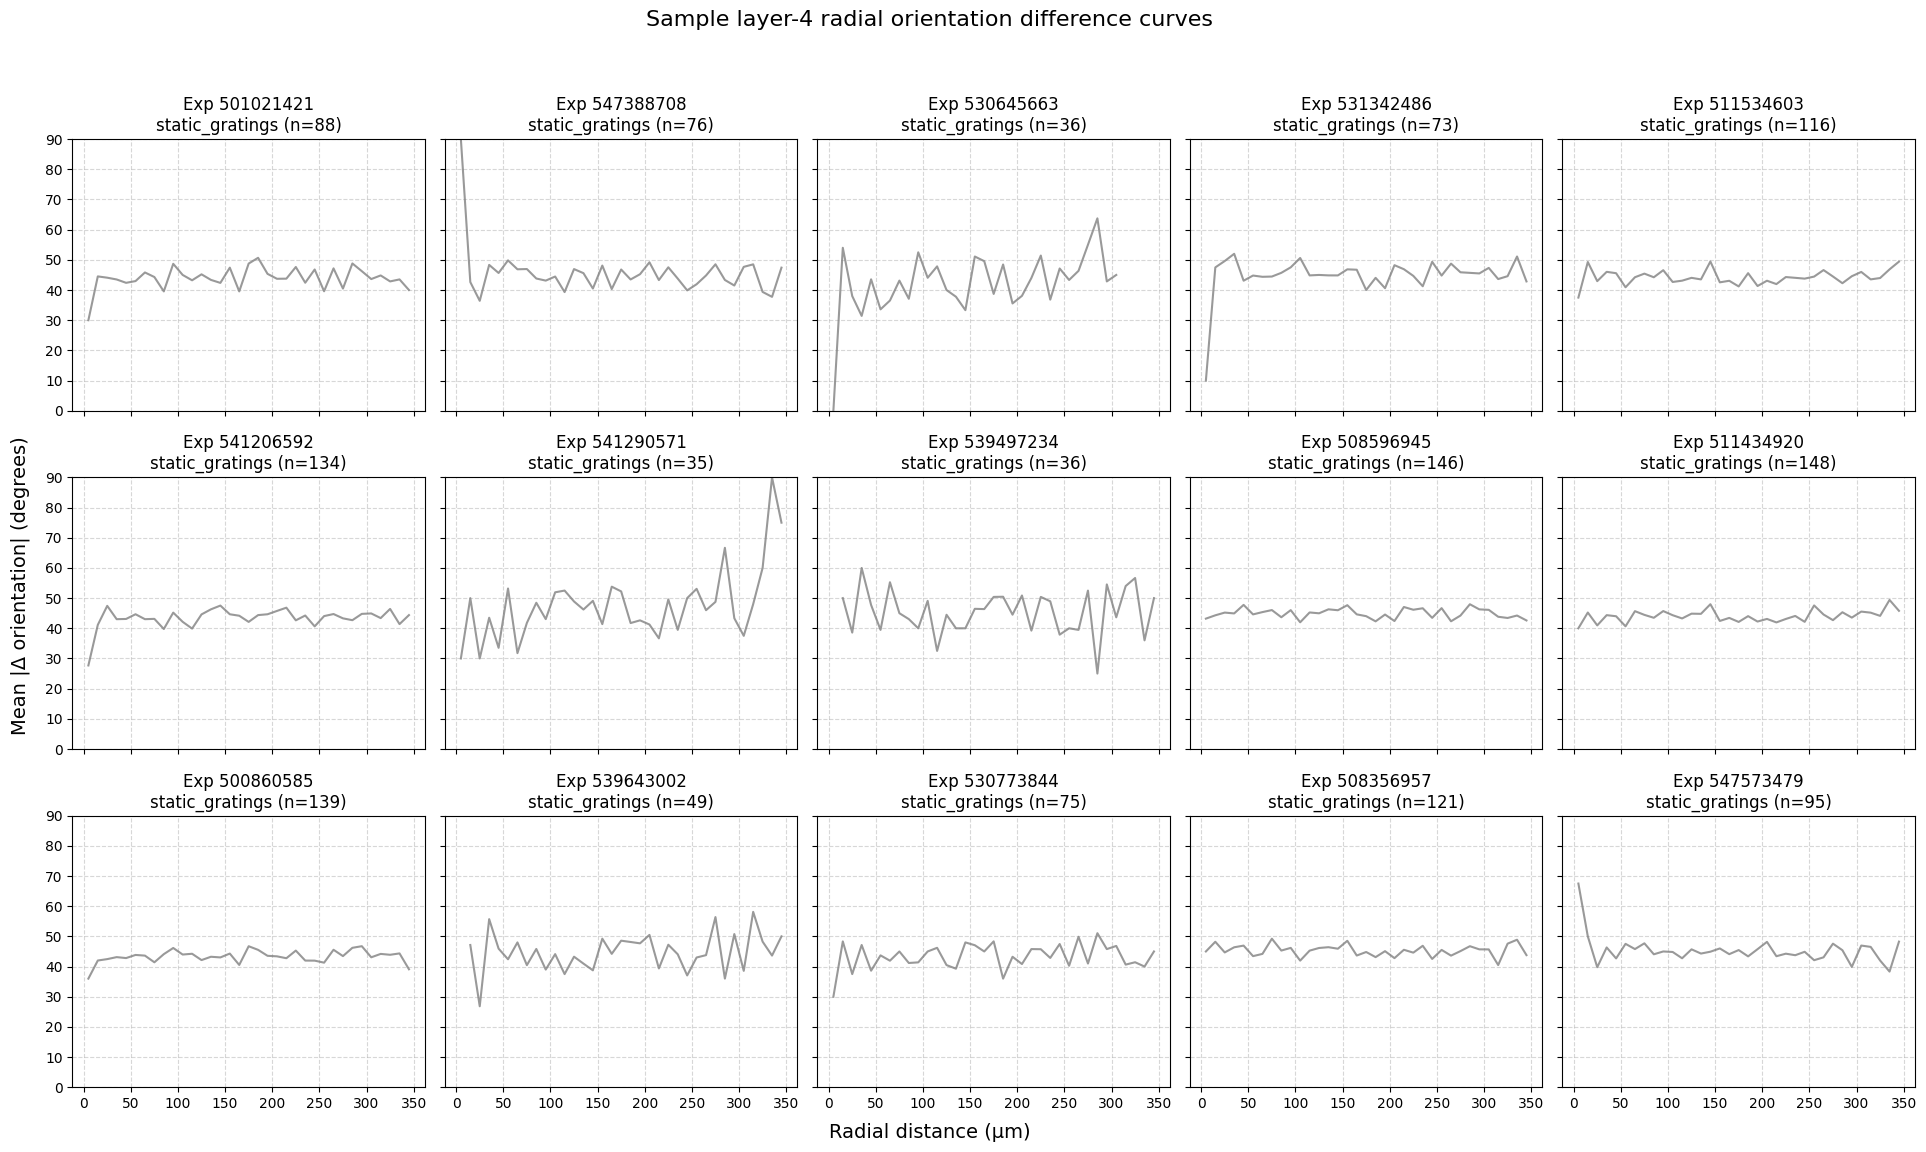

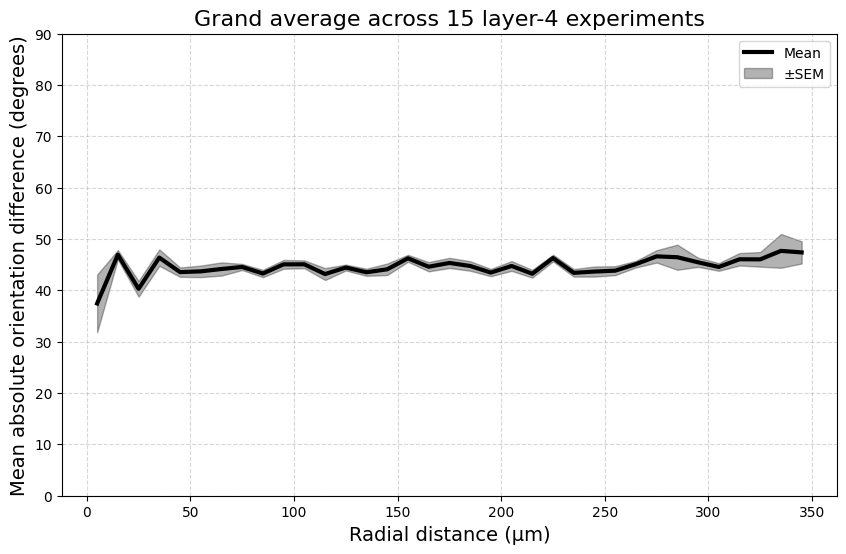

In [27]:
%matplotlib inline
print(f"\nSuccessfully processed {len(curves)} layer-4 experiments")

if len(curves) == 0:
    raise ValueError("No qualifying layer-4 experiments found — check cache")

# Grand average
curves_arr = np.array(curves)
grand_mean = np.nanmean(curves_arr, axis=0)
grand_sem = np.nanstd(curves_arr, axis=0) / np.sqrt(len(curves))

# Sample individual curves (up to 25)
sample_size = min(25, len(curves))
sample_idx = random.sample(range(len(curves)), sample_size)

cols = 5
rows = int(np.ceil(sample_size / cols))
fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), sharex=True, sharey=True)
axs = axs.flat

for i, idx in enumerate(sample_idx):
    ax = axs[i]
    ax.plot(bin_centers, curves[idx], 'gray', alpha=0.8)
    info = exp_info[idx]
    ax.set_title(f"Exp {info['exp_id']}\n{info['stim']} (n={info['n_cells']})")
    ax.set_ylim(0, 90)
    ax.grid(True, ls='--', alpha=0.5)

for j in range(i+1, len(axs)):
    axs[j].axis('off')

fig.text(0.5, 0.04, 'Radial distance (µm)', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Mean |Δ orientation| (degrees)', va='center', rotation='vertical', fontsize=14)
plt.suptitle('Sample layer-4 radial orientation difference curves', fontsize=16)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

# Grand average
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, grand_mean, 'k-', lw=3, label='Mean')
plt.fill_between(bin_centers, grand_mean - grand_sem, grand_mean + grand_sem,
                 color='k', alpha=0.3, label='±SEM')
plt.xlabel('Radial distance (µm)', fontsize=14)
plt.ylabel('Mean absolute orientation difference (degrees)', fontsize=14)
plt.title(f'Grand average across {len(curves)} layer-4 experiments', fontsize=16)
plt.ylim(0, 90)
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.show()

In [65]:
X = X.view(X.shape[0], -1)

In [63]:
#torch.save(X, './neuro.pt')
X = torch.load('./neuro.pt')

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy.core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch

In [12]:
def plot_umap_with_angles_3d(code_tracker, variable, n_components=3, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42, fs=22):
    """
    Plot UMAP embedding of codes with HSV color based on grating angle.

    code_tracker: list of torch.Tensor, each of shape [C, H, W] or [1, H, W]
    angles: list or np.array of floats, same length as code_tracker, grating angles in degrees
    n_components: 2 or 3
    """
    
    assert n_components in (2,3), "n_components must be 2 or 3"
    
    # Convert codes to 2D array [N, D]
    codes = torch.cat([c.view(1, -1) for c in code_tracker], dim=0).numpy()
    
    variable = np.array(variable)
    variable = variable - variable.min()
    variable = variable / (variable.max() + 1e-11)
    
    # UMAP embedding
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state
    )
    
    embedding = reducer.fit_transform(codes)
    
    # Convert angles to HSV colors
    hsv_colors = np.zeros((len(variable), 3))
    hsv_colors[:, 0] = variable  # hue from 0-1
    hsv_colors[:, 1] = 1.0  # saturation
    hsv_colors[:, 2] = 1.0  # value
    rgb_colors = mcolors.hsv_to_rgb(hsv_colors)
    
    # Plot
    if n_components == 2:
        plt.figure(figsize=(6,6))
        plt.scatter(embedding[:,0], embedding[:,1], c=rgb_colors, s=20)
        plt.xlabel("UMAP-1", fontsize=fs)
        plt.ylabel("UMAP-2", fontsize=fs)
        plt.xticks(ticks=[])
        plt.yticks(ticks=[])
        plt.axis('equal')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
    else:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Scatter points
        ax.scatter(embedding[:,0], embedding[:,1], embedding[:,2], c=rgb_colors, s=50)
        
        # Labels with padding
        ax.set_xlabel("UMAP-1", fontsize=fs, labelpad=0)
        ax.set_ylabel("UMAP-2", fontsize=fs, labelpad=0)
        ax.set_zlabel("UMAP-3", fontsize=fs, labelpad=0)  # large pad to avoid clipping
        
        # Manually move the Z-label even higher
        ax.zaxis.set_label_coords(0.5, 1.05)  # x in [0,1], y>1 moves it up
        
        # Hide tick labels but keep the grid
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])
        
        # Optional: rotate view for better visibility
        ax.view_init(elev=50, azim=20)
        
        # Adjust subplot margins to avoid clipping
        plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
        
    plt.show()
    return embedding

In [247]:
mask = (torch.tensor((wavelengths*100).round()==8).float() * torch.tensor((phases*100).round()==0).float()) > 0

/home/nicolamendini/allen_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


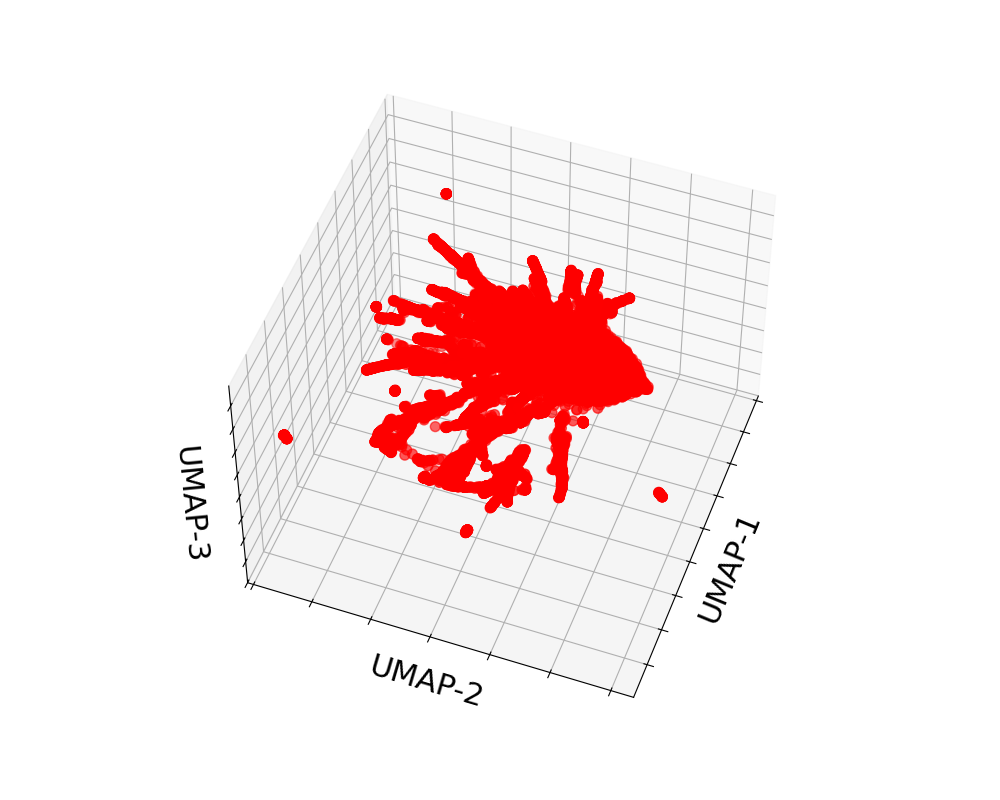

array([[ 0.5471277 , -1.0036725 ,  0.8833589 ],
       [ 0.5443738 , -0.9911756 ,  0.8815339 ],
       [ 0.5463348 , -0.99251086,  0.8844324 ],
       ...,
       [ 0.54445326, -0.9818056 ,  0.8786814 ],
       [ 0.54326457, -0.9952996 ,  0.88637364],
       [ 0.5446238 , -0.9939966 ,  0.880828  ]], dtype=float32)

In [15]:
%matplotlib widget
plot_umap_with_angles_3d(torch.tensor(dff_traces), torch.zeros(dff_traces.shape[0]))

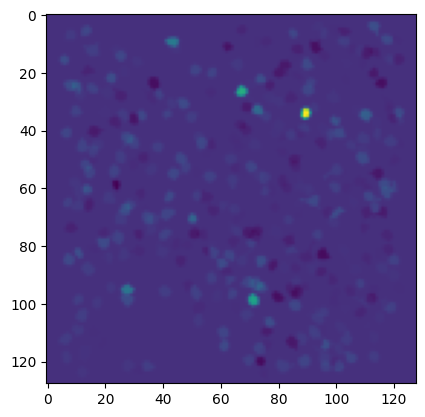

In [212]:
%matplotlib inline
s = random.randint(0, X.shape[0])
plt.imshow(torch.tensor(X[s]).view(n,n))
plt.show()

In [32]:
import torch
import numpy as np
from scipy.ndimage import gaussian_filter, maximum_filter
import matplotlib.pyplot as plt

def better_detect_neurons(
    activity: torch.Tensor,
    sigma: float = 1,
    min_distance: int = 4,
    percentile: float = 95.0,
    rel_threshold: float = 0.03,
    footprint_size: int = 5,
    plot: bool = False
):
    """
    Improved neuron detection using standard techniques from calcium imaging pipelines.
    
    This is generally more robust, faster, and accurate than iterative greedy removal:
    - Uses a summary statistic (peak activity percentile) across time for stability.
    - Gaussian smoothing + regional maxima detection.
    - Non-maximum suppression (NMS) to handle close/overlapping candidates.
    - Subpixel center-of-mass refinement.
    
    Parameters:
    - activity: torch.Tensor (B, N) flattened or (B, n, n)
    - sigma: Gaussian blur std (tune to ~half neuron radius)
    - min_distance: Minimum pixel distance between detected centers (NMS)
    - percentile: Percentile for summary map (95–99 captures peaks, robust to noise)
    - rel_threshold: Relative threshold (fraction of max in summary map)
    - footprint_size: Size of square footprint for regional maxima (odd, ~neuron diameter)
    - plot: Show diagnostic plots
    
    Returns:
    - indices: torch.LongTensor of shape (K,) with flattened indices (sorted spatially)
    - centers: list of (y, x) subpixel coordinates
    - summary_map: the computed summary map (for inspection)
    """
    # Reshape
    if activity.dim() == 2:
        B, N = activity.shape
        n = int(np.sqrt(N))
        assert n * n == N
        activity = activity.reshape(B, n, n)
    elif activity.dim() == 3:
        B, n, _ = activity.shape
    else:
        raise ValueError("Input must be (B, N) or (B, n, n)")

    H, W = n, n
    act_np = activity.cpu().numpy().astype(np.float32)

    # Robust summary map: high percentile of positive activity (handles negatives/depth bias)
    # Deeper neurons may have weaker average but still hit high peaks when active
    positive_act = np.maximum(act_np, 0)
    summary_map = np.percentile(positive_act, percentile, axis=0)

    # Smooth for reliable peak detection
    blurred = gaussian_filter(summary_map, sigma=sigma)

    # Absolute threshold (relative to global max)
    thresh = rel_threshold * blurred.max()

    # Regional maxima using square footprint
    footprint = np.ones((footprint_size, footprint_size))
    local_maxima = maximum_filter(blurred, footprint=footprint) == blurred
    candidates_mask = (blurred > thresh) & local_maxima

    # Get candidate coordinates and strengths
    cy_cand, cx_cand = np.where(candidates_mask)
    strengths = blurred[cy_cand, cx_cand]

    # Sort by strength descending
    order = np.argsort(-strengths)
    cy_cand = cy_cand[order]
    cx_cand = cx_cand[order]
    strengths = strengths[order]

    # Non-maximum suppression: keep only if far enough from higher-strength neighbors
    keep = []
    for i in range(len(cy_cand)):
        if not keep:
            keep.append(i)
            continue
        dists = np.sqrt((cy_cand[i] - np.array(cy_cand)[keep])**2 +
                        (cx_cand[i] - np.array(cx_cand)[keep])**2)
        if np.min(dists) >= min_distance:
            keep.append(i)

    # Refine with center-of-mass on original summary_map (subpixel accuracy)
    final_centers = []
    half = footprint_size // 2
    for idx in keep:
        y0, x0 = cy_cand[idx], cx_cand[idx]
        y1 = max(0, y0 - half)
        y2 = min(H, y0 + half + 1)
        x1 = max(0, x0 - half)
        x2 = min(W, x0 + half + 1)
        patch = summary_map[y1:y2, x1:x2]

        if np.sum(patch) == 0:
            continue

        py, px = np.indices(patch.shape)
        total = np.sum(patch)
        cy_local = np.sum(py * patch) / total
        cx_local = np.sum(px * patch) / total
        cy = cy_local + y1
        cx = cx_local + x1
        final_centers.append((cy, cx))

    # Convert to integer indices (rounded, unique, sorted row-major)
    indices_list = []
    seen = set()
    for cy, cx in final_centers:
        iy = int(np.round(cy))
        ix = int(np.round(cx))
        idx_flat = iy * W + ix
        if 0 <= iy < H and 0 <= ix < W and idx_flat not in seen:
            seen.add(idx_flat)
            indices_list.append(idx_flat)

    # Sort spatially (row-major)
    indices_list.sort()
    indices = torch.tensor(indices_list, dtype=torch.long)

    # Plotting
    if plot:
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 4, 1)
        plt.imshow(summary_map, cmap='hot')
        plt.title('Summary Map (95th %ile)')
        plt.colorbar()

        plt.subplot(1, 4, 2)
        plt.imshow(blurred, cmap='hot')
        plt.title('Blurred')
        plt.colorbar()

        plt.subplot(1, 4, 3)
        plt.imshow(blurred, cmap='hot')
        plt.plot(cx_cand, cy_cand, 'c.', alpha=0.5, label='Candidates')
        plt.plot(cx_cand[keep], cy_cand[keep], 'wo', markersize=8, markeredgecolor='k', label='After NMS')
        plt.legend()
        plt.title('Peak Candidates + NMS')

        plt.subplot(1, 4, 4)
        plt.imshow(summary_map, cmap='hot')
        for cy, cx in final_centers:
            plt.plot(cx, cy, 'wo', markersize=10, markeredgecolor='black', markeredgewidth=1.5)
        plt.title(f'Final {len(final_centers)} Neurons')
        plt.colorbar()

        plt.tight_layout()
        plt.show()

        print(f"Detected {len(indices)} neurons")
        print("Flattened indices:", indices.tolist())

    return indices, final_centers, summary_map

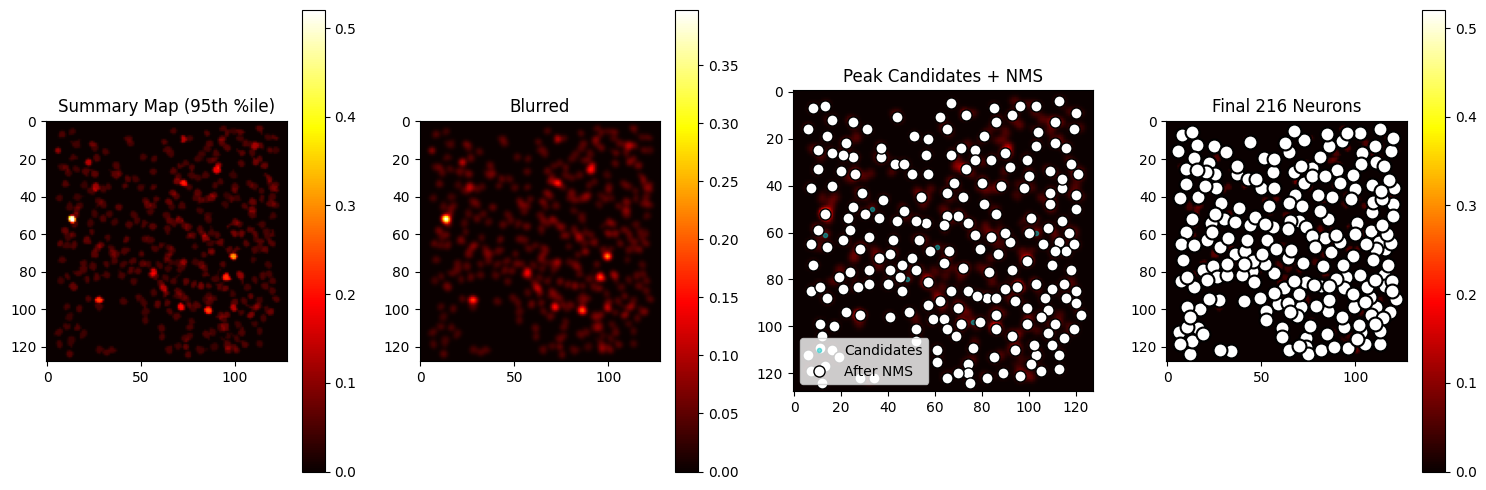

Detected 216 neurons
Flattened indices: [625, 707, 781, 864, 871, 904, 981, 1272, 1353, 1373, 1452, 1470, 1552, 1689, 1750, 1775, 2054, 2079, 2113, 2167, 2280, 2446, 2483, 2513, 2617, 2838, 2927, 3047, 3109, 3143, 3188, 3210, 3277, 3344, 3418, 3477, 3512, 3523, 3609, 3621, 3789, 3796, 3811, 4011, 4015, 4086, 4234, 4297, 4316, 4372, 4461, 4506, 4530, 4537, 4601, 4708, 4850, 5060, 5072, 5136, 5208, 5255, 5346, 5362, 5533, 5569, 5613, 5752, 5814, 5832, 5926, 6225, 6253, 6297, 6520, 6575, 6669, 6686, 6742, 6849, 6854, 6935, 6948, 7013, 7084, 7092, 7154, 7224, 7242, 7360, 7532, 7562, 7576, 7770, 7780, 7797, 7885, 7968, 8020, 8085, 8106, 8117, 8284, 8305, 8327, 8426, 8439, 8462, 8604, 8655, 8762, 8770, 8815, 8820, 8873, 8919, 9124, 9138, 9315, 9408, 9480, 9518, 9582, 9672, 9760, 9769, 9780, 9821, 9846, 9880, 9939, 10131, 10157, 10425, 10528, 10536, 10599, 10611, 10635, 10651, 10719, 10773, 10842, 10862, 10887, 10926, 10947, 10954, 11000, 11214, 11278, 11346, 11350, 11371, 11380, 11454, 11486

In [36]:
indices, final_centers, summary_map = better_detect_neurons(torch.tensor(X), plot=True)

In [68]:
oris.min(), oris.max()

(0.0, 150.0)

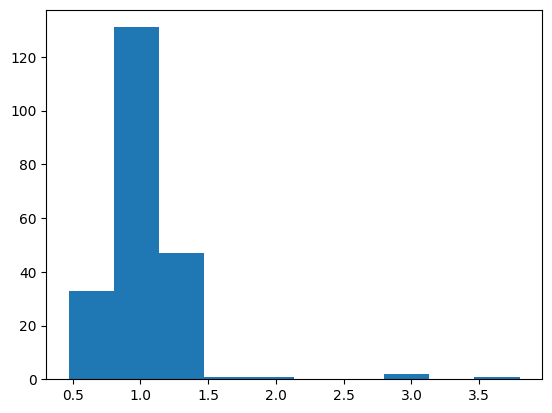

In [114]:
%matplotlib inline
x = torch.tensor(X[:, indices])
x -= x.min(dim=0, keepdim=True)[0]
x /= x.mean(dim=0, keepdim=True)
plt.hist(x[random.randint(0,x.shape[0])])
plt.show()

In [249]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import percentile_filter
from skimage.draw import disk 

def extract_robust_neuron_traces(
    activity: torch.Tensor,
    final_centers: list[tuple[float, float]], 
    roi_radius: float = 2.0, 
    # NEUROPIL SETTINGS
    neuropil_subtract: bool = True,  # CHANGED: Default to True
    neuropil_inner_r: float = 3.0,
    neuropil_outer_r: float = 6.0,
    neuropil_alpha: float = 0.7,     # Scaling factor (0.7 is standard for GCaMP6)
    # BASELINE SETTINGS
    window_size_frames: int = 1800,  # ~1-2 mins depending on framerate
    f0_percentile: float = 10.0,
):
    """
    Improved extraction with Neuropil Subtraction and Rolling Baseline.
    """
    device = activity.device
    
    # 1. Reshape and Prep
    if activity.dim() == 2:
        B, N = activity.shape
        n = int(np.sqrt(N))
        activity = activity.reshape(B, n, n)
    B, H, W = activity.shape
    C = len(final_centers)
    act_np = activity.cpu().numpy().astype(np.float32)

    # 2. Mask Generation (Same as your code)
    masks = np.zeros((C, H, W), dtype=np.float32)
    np_masks = np.zeros((C, H, W), dtype=np.float32)

    for i, (cy, cx) in enumerate(final_centers):
        iy, ix = int(np.round(cy)), int(np.round(cx))
        
        # ROI
        rr, cc = disk((iy, ix), roi_radius, shape=(H, W))
        masks[i, rr, cc] = 1.0
        
        # Neuropil Ring
        if neuropil_subtract:
            rr_out, cc_out = disk((iy, ix), neuropil_outer_r, shape=(H, W))
            rr_in, cc_in = disk((iy, ix), neuropil_inner_r, shape=(H, W))
            np_masks[i, rr_out, cc_out] = 1.0
            np_masks[i, rr_in, cc_in] = 0.0

    # Normalize Masks
    masks /= np.maximum(masks.sum(axis=(1,2), keepdims=True), 1.0)
    if neuropil_subtract:
        np_masks /= np.maximum(np_masks.sum(axis=(1,2), keepdims=True), 1.0)

    # 3. Extract Raw Traces
    # Dot product: (Frames x H x W) * (Neurons x H x W) -> (Frames x Neurons)
    roi_traces = np.tensordot(act_np, masks, axes=([1,2], [1,2]))
    
    if neuropil_subtract:
        np_traces = np.tensordot(act_np, np_masks, axes=([1,2], [1,2]))
        # Subtract scaled neuropil
        raw_traces = roi_traces - (neuropil_alpha * np_traces)
    else:
        raw_traces = roi_traces

    # 4. Compute Rolling dF/F (Fixes Drift)
    print("Calculating rolling baseline (this may take a moment)...")
    # We use scipy's percentile filter over the time axis (axis 0)
    # This ensures F0 follows the downward drift of photobleaching
    F0 = percentile_filter(raw_traces, percentile=f0_percentile, size=(window_size_frames, 1))
    
    # Avoid division by zero or negative F0
    F0 = np.maximum(F0, 1e-5)
    
    dff = (raw_traces - F0) / F0
    
    return torch.from_numpy(dff).to(device)

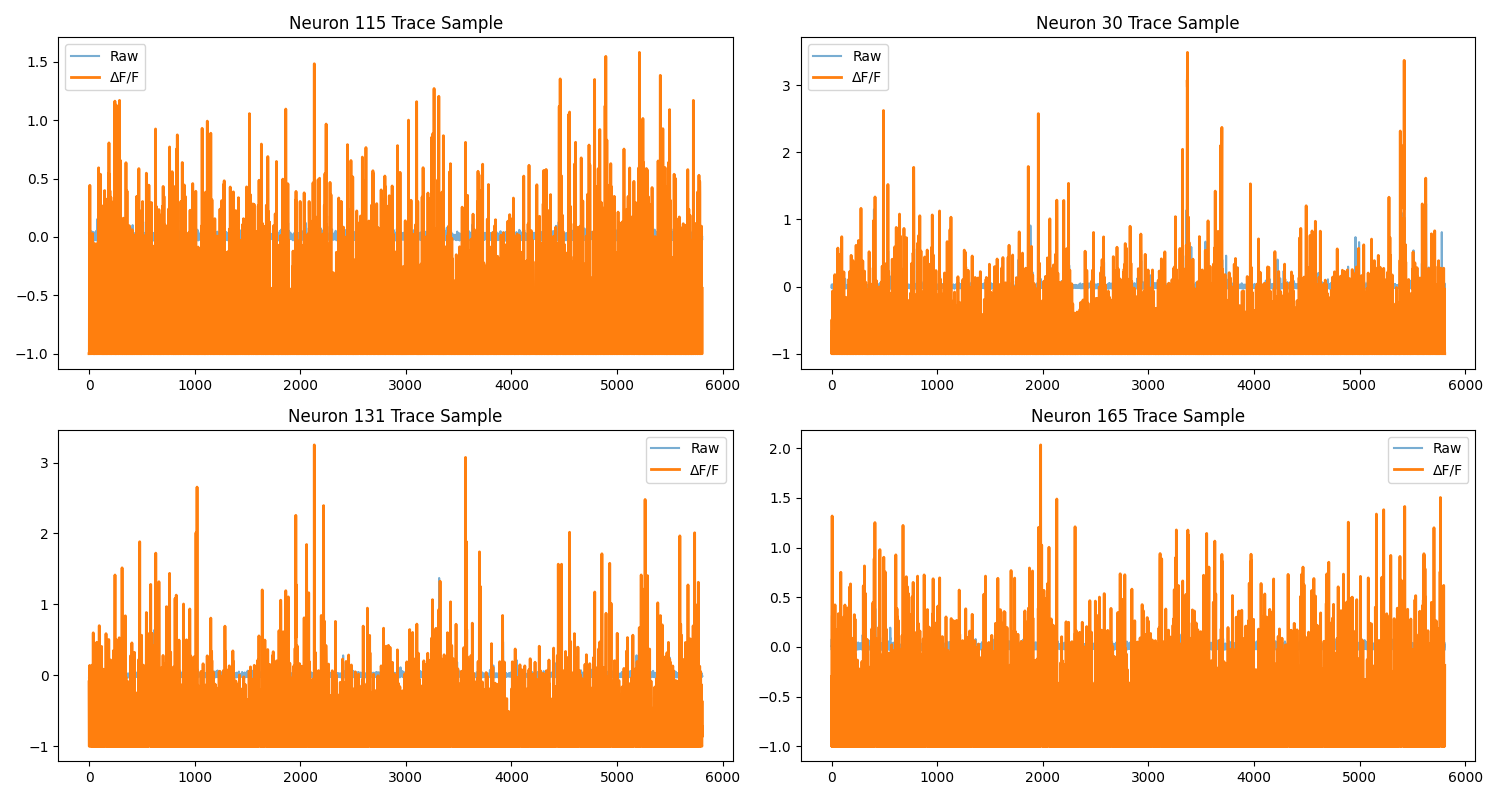

Extracted 216 clean traces (B=5807)
Mean ΔF/F amplitude: 0.772
Tip: Use traces_df for orientation responses (average over stimulus periods)


In [250]:
traces_df, raw_traces = extract_clean_neuron_traces(torch.tensor(X), final_centers)

In [128]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def measure_orientation_preference(
    traces_df: torch.Tensor,  # (B, C) clean ΔF/F traces
    stimulus_ori_per_frame: np.ndarray,  # Array length B: orientation per frame (-1 for blanks)
    final_centers: list[tuple[float, float]],  # REQUIRED for spatial plot: (y, x) centers
    unique_oris: list[float] | np.ndarray | None = None,  # Optional: if None, infer from stimulus_ori_per_frame
    blank_label: float = -1.0,
    min_osi: float = 0.2,
    plot: bool = True,
    debug: bool = True
):
    """
    Complete pipeline for orientation preference from time-series traces.
    Now includes proper spatial plotting with final_centers.
    """
    B, C = traces_df.shape
    if len(final_centers) != C:
        raise ValueError(f"final_centers length ({len(final_centers)}) must match num neurons ({C})")
    
    stimulus_ori_per_frame = np.asarray(stimulus_ori_per_frame)
    if len(stimulus_ori_per_frame) != B:
        raise ValueError("stimulus_ori_per_frame length must match traces_df rows")
    
    # Infer unique_oris if not provided
    if unique_oris is None:
        unique_oris = np.sort(np.unique(stimulus_ori_per_frame[stimulus_ori_per_frame != blank_label]))
    else:
        unique_oris = np.sort(np.asarray(unique_oris))
    
    num_ori = len(unique_oris)
    if num_ori == 0:
        raise ValueError("No valid orientations found")
    
    # Blank subtraction
    if blank_label in stimulus_ori_per_frame:
        blank_frames = stimulus_ori_per_frame == blank_label
        if blank_frames.sum() > 0:
            blank_mean = traces_df[blank_frames].mean(dim=0, keepdim=True)
            traces_df = traces_df - blank_mean
            if debug:
                print("Applied blank subtraction")
    
    # Mean response per orientation
    responses = np.full((num_ori, C), np.nan)
    trial_counts = np.zeros(num_ori)
    
    for i, ori in enumerate(unique_oris):
        ori_frames = stimulus_ori_per_frame == ori
        count = ori_frames.sum()
        if count > 0:
            responses[i] = traces_df[ori_frames].mean(dim=0).cpu().numpy()
            trial_counts[i] = count
    
    if debug:
        print(f"Unique orientations: {unique_oris.tolist()}")
        print(f"Mean trials per ori: {trial_counts.mean():.1f} (±{trial_counts.std():.1f})")
        print(f"Response range: {np.nanmin(responses):.3f} to {np.nanmax(responses):.3f}")
    
    from scipy.optimize import curve_fit

    def von_mises(theta, R0, Rp, kappa, theta_p):
        return R0 + Rp * np.exp(kappa * (np.cos(np.deg2rad(theta - theta_p)) - 1))  # Normalized form
    
    # Inside measure_orientation_preference, replace vector averaging with:
    po_deg = np.zeros(C)
    osi = np.zeros(C)
    responses = responses  # Use raw (allow negatives)
    
    for n in range(C):
        resp = responses[:, n]
        valid = ~np.isnan(resp)
        if valid.sum() < 3:
            continue
        
        theta = unique_oris[valid]
        try:
            p0 = [resp.min(), (resp.max() - resp.min()), 2.0, po_deg[n] if osi[n]>0 else theta[np.argmax(resp)]]
            popt, _ = curve_fit(von_mises, theta, resp, p0=p0, bounds=([resp.min()-1, 0, 0, -180], [resp.max()+1, np.ptp(resp)+1, 10, 360]))
            R0, Rp, kappa, theta_p = popt
            po_deg[n] = theta_p % 180
            osi[n] = 1 - np.exp(-kappa)  # Common OSI from bandwidth
            # Alternative: osi[n] = Rp / (R0 + Rp + 1e-8) if R0 high
        except:
            osi[n] = 0
    
    # Then proceed with plotting (use this new po_deg/osi)
    
    if debug:
        print(f"Mean OSI: {np.nanmean(osi):.3f} ± {np.nanstd(osi):.3f}")
        print(f"Max OSI: {np.nanmax(osi):.3f}")
        print(f"Fraction tuned (OSI ≥ {min_osi}): {(osi >= min_osi).mean():.2%}")
        
        # Example tuning curves
        plt.figure(figsize=(15, 6))
        examples = np.random.choice(C, size=min(15, C), replace=False)
        for i, nid in enumerate(examples):
            plt.subplot(3, 5, i+1)
            valid = ~np.isnan(responses[:, nid])
            plt.plot(unique_oris[valid], responses[valid, nid], 'o-')
            plt.title(f"Neuron {nid}\nOSI={osi[nid]:.3f}")
            plt.xticks(unique_oris[::2])
        plt.tight_layout()
        plt.show()
        
        # OSI histogram
        plt.figure()
        plt.hist(osi[~np.isnan(osi)], bins=50, range=(0,1))
        plt.axvline(min_osi, color='r', linestyle='--')
        plt.title("OSI Distribution")
        plt.xlabel("Orientation Selectivity Index")
        plt.show()
    
    if plot:
        ys, xs = zip(*final_centers)
        xs = np.array(xs)
        ys = np.array(ys)
        
        plt.figure(figsize=(10, 10))
        ax = plt.gca()
        
        # Untuned (gray)
        low_osi = osi < min_osi
        if np.any(low_osi):
            ax.scatter(xs[low_osi], ys[low_osi], c='lightgray', s=30, alpha=0.7)
        
        # Tuned (colored, sized by OSI)
        tuned = osi >= min_osi
        num_tuned = np.sum(tuned)
        if num_tuned > 0:
            sizes = 40 + 250 * (osi[tuned] - min_osi) / (osi[tuned].max() - min_osi + 1e-8)
            scatter = ax.scatter(xs[tuned], ys[tuned], c=po_deg[tuned], cmap='hsv',
                                 vmin=0, vmax=180, s=sizes, edgecolor='black', linewidth=0.5)
            # Colorbar
            sm = ScalarMappable(norm=Normalize(0, 180), cmap='hsv')
            sm.set_array([])
            plt.colorbar(sm, ax=ax, shrink=0.7, label='Preferred Orientation (°)')
        
        title = f'Preferred Orientation Map (OSI ≥ {min_osi})\n{num_tuned}/{C} tuned neurons'
        if num_tuned == 0:
            title += ' — try lowering min_osi'
        ax.set_title(title)
        ax.axis('equal')
        ax.invert_yaxis()
        ax.axis('off')
        plt.show()
    
    return po_deg, osi, responses, unique_oris

Unique orientations: [0, 30, 60, 90, 120, 150]
Mean trials per ori: 967.8 (±5.9)
Response range: -0.798 to -0.631
Mean OSI: 0.768 ± 0.382
Max OSI: 1.000
Fraction tuned (OSI ≥ 0.2): 80.56%


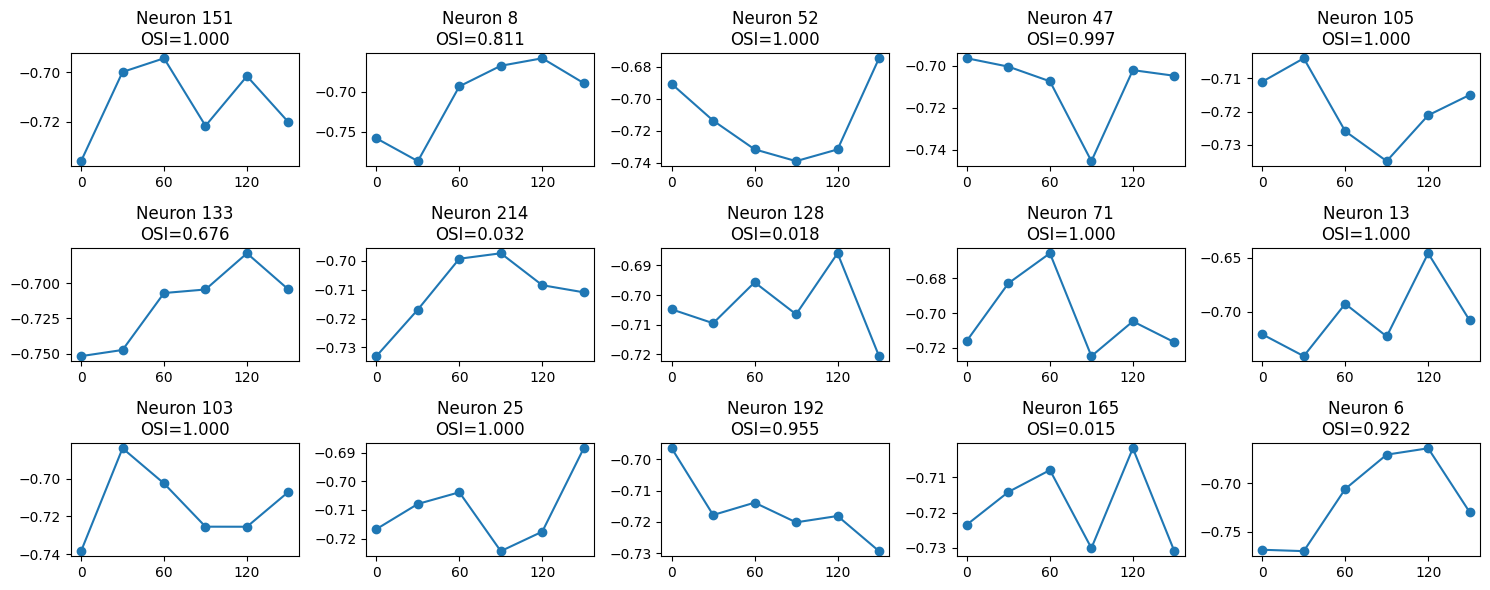

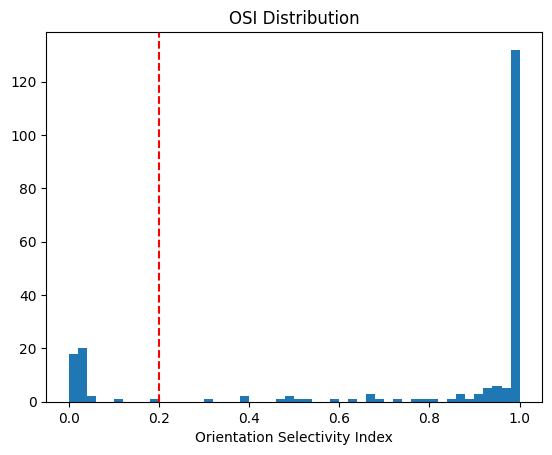

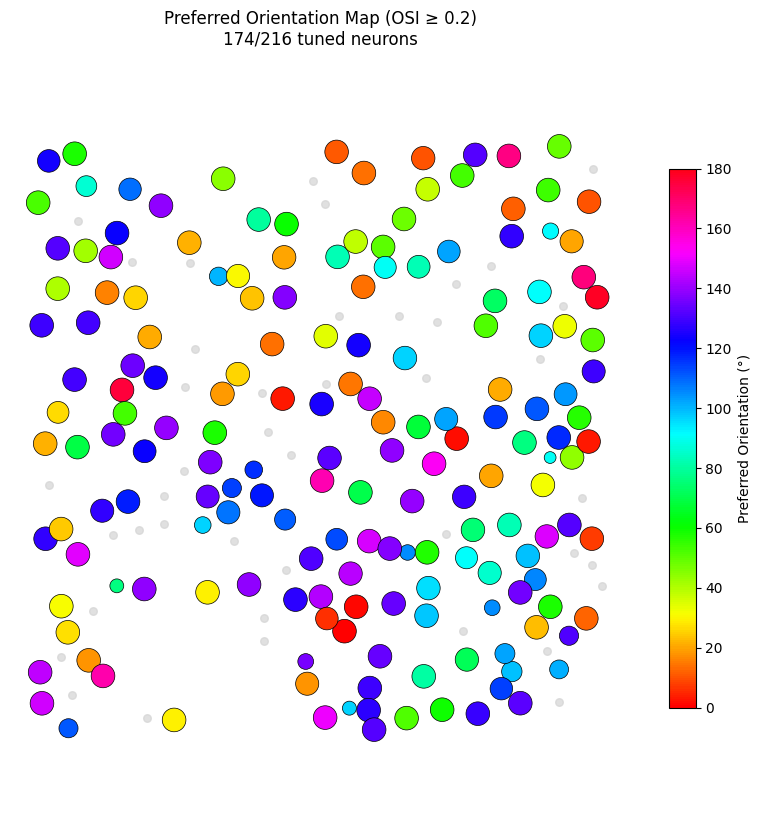

In [131]:
po_deg, osi, responses, unique_oris = measure_orientation_preference(traces_df, oris, final_centers, unique_oris=[0, 30, 60, 90, 120, 150])

In [135]:
po_deg.shape, len(final_centers), traces_df.shape

((216,), 216, torch.Size([5807, 216]))

In [202]:
import numpy as np
import matplotlib.pyplot as plt

def neuron_functional_layout(
    centers,
    orientation_preferences,
    df_traces,
    top_k=6,
    threshold=0.0,          # only connect if correlation > this value
    iterations=3000,
    rep_strength=1e4,        # increase to spread more, decrease to allow tighter clusters
    attr_strength=0.01,      # increase to pull correlated neurons closer
    initial_temp=20.0        # higher = more initial movement
):
    """
    Parameters
    ----------
    centers : list of (x, y) tuples or Nx2 array
        Original imaging positions of the neurons.
    orientation_preferences : array-like of length N
        Preferred orientation in degrees (0–180).
    df_traces : array-like of shape (B, N)
        ΔF/F traces over time (B frames/timepoints, N neurons).
    
    Returns
    -------
    final_positions : Nx2 array
        New 2D coordinates after force-directed rearrangement.
    fig : matplotlib figure
        Side-by-side plot (original vs. functional layout).
    """
    centers = np.asarray(centers)
    ori = np.asarray(orientation_preferences)
    traces = np.asarray(df_traces)
    
    if traces.ndim != 2:
        raise ValueError("df_traces must be 2D (timepoints x neurons)")
    B, N = traces.shape
    if not (N == len(centers) == len(ori)):
        raise ValueError("Number of neurons must match across inputs")
    
    if N < 2:
        return centers, None
    
    # Pearson correlation matrix
    corr = np.corrcoef(traces.T)  # NxN
    np.fill_diagonal(corr, 0.0)
    
    # Build undirected edges for top-k highest positive correlations
    connected_pairs = set()
    for i in range(N):
        # Sort neighbors by correlation descending
        sorted_idx = np.argsort(corr[i])[::-1]
        count = 0
        for j in sorted_idx:
            if j == i:
                continue
            c = corr[i, j]
            if c <= threshold:
                break  # later ones are even lower
            pair = frozenset({i, j})
            connected_pairs.add(pair)
            count += 1
            if count == top_k:
                break
    
    # Force-directed layout starting from original centers
    pos = centers.astype(float).copy()
    
    for it in range(iterations):
        forces = np.zeros_like(pos)
        
        # === Repulsion (all pairs) ===
        delta = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]  # N x N x 2
        dist = np.linalg.norm(delta, axis=-1)
        dist = np.maximum(dist, 1e-6)
        rep_mag = rep_strength / (dist ** 2)
        rep_dir = delta / dist[..., np.newaxis]
        rep_force = rep_dir * rep_mag[..., np.newaxis]
        # Zero self-repulsion
        rep_force[np.arange(N), np.arange(N), :] = 0
        forces += np.sum(rep_force, axis=1)
        
        # === Attraction (only connected pairs) ===
        for pair in connected_pairs:
            i, j = list(pair)
            delta_vec = pos[i] - pos[j]
            d = np.linalg.norm(delta_vec)
            if d < 1e-6:
                continue
            w = corr[i, j]
            mag = attr_strength * w * d          # stronger when far or high corr
            dir_i_to_j = -delta_vec / d
            force_i = dir_i_to_j * mag
            forces[i] += force_i
            forces[j] -= force_i
        
        # Cooling schedule + limited step size
        temperature = initial_temp * ((iterations - it - 1) / iterations) ** 2
        force_norms = np.linalg.norm(forces, axis=1, keepdims=True)
        displacement = forces * (temperature / (force_norms + 1e-6))
        pos += displacement
    
    # Center the final layout
    pos -= np.mean(pos, axis=0)
    
    # === Plotting ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    for ax in (ax1, ax2):
        ax.set_aspect('equal')
        ax.axis('off')
    
    scatter1 = ax1.scatter(centers[:, 0], centers[:, 1],
                           c=ori / 180.0, cmap='hsv', s=200, edgecolor='k', linewidth=0.2)
    ax1.set_title('Original Anatomical Positions')
    
    scatter2 = ax2.scatter(pos[:, 0], pos[:, 1],
                           c=ori / 180.0, cmap='hsv', s=200, edgecolor='k', linewidth=0.2)
    ax2.set_title('Functional Layout\n(top-6 correlated attraction + global repulsion)')

    
    plt.tight_layout()
    plt.show()
    
    return pos, fig

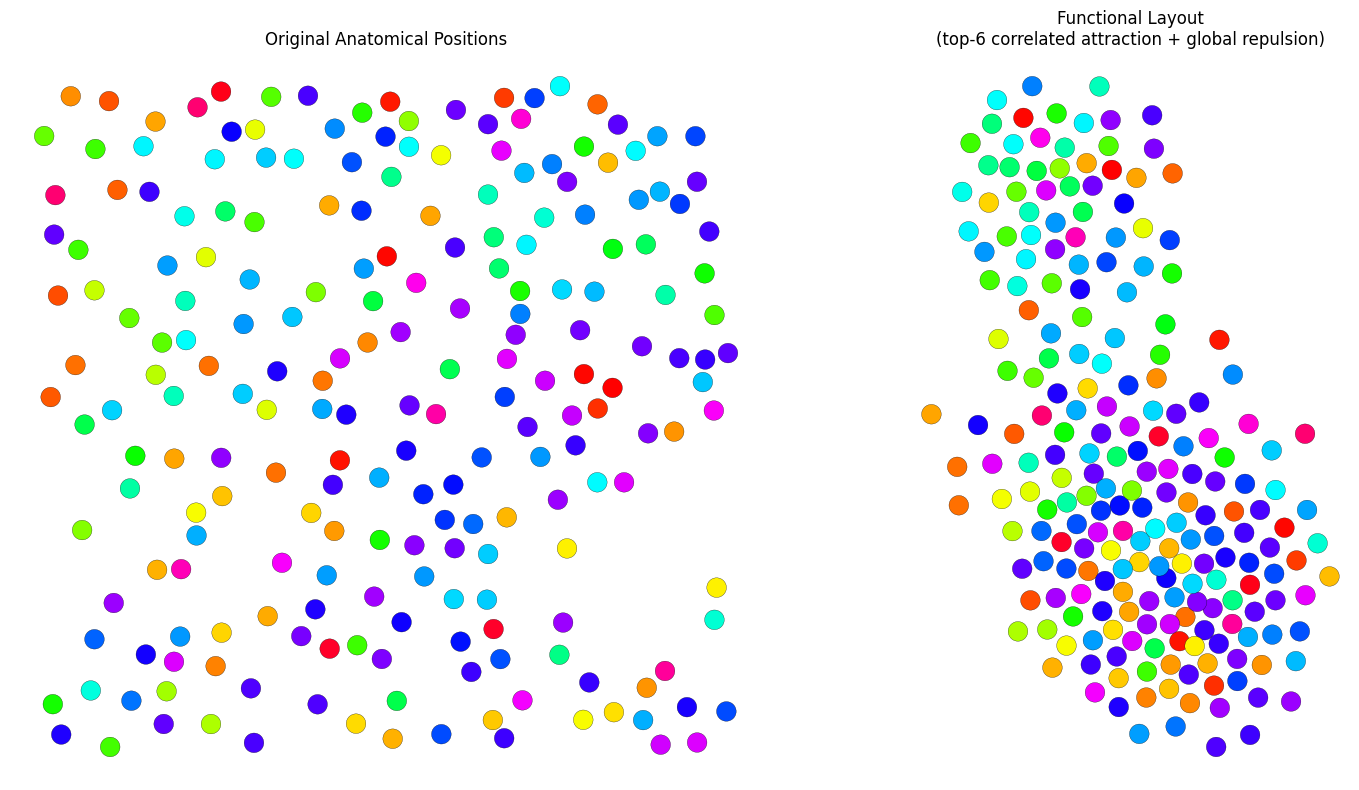

In [210]:
pos, fig = neuron_functional_layout(final_centers, po_deg, traces_df)

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def compute_radial_averages(coords, preferences, df_traces, bin_edges=None, num_bins=15):
    """
    Computes and plots radially averaged metrics vs. distance in a neuronal population.
    
    Parameters:
    -----------
    coords : array-like, shape (N, 2) or list of (x, y) tuples
        Spatial coordinates of neuron centers.
    preferences : array-like, shape (N,)
        Orientation preferences in degrees (0–180).
    df_traces : array-like, shape (T, N)
        DeltaF/F (or similar) traces over time (T time points, N neurons).
    bin_edges : array-like, optional
        Bin edges for radial distance (in the same units as coords). If None, automatically
        creates `num_bins` evenly spaced bins from 0 to the maximum pairwise distance.
    num_bins : int, default 15
        Number of bins to use if bin_edges is None.
    
    Returns:
    --------
    dict with keys:
        'bin_centers', 'ori_diff_mean', 'ori_diff_std',
        'corr_mean', 'corr_std'
    
    The function also displays a plot with error bars showing the standard deviation
    across origin neurons for each bin.
    """
    # Convert inputs to numpy arrays
    coords = np.asarray(coords)
    if coords.shape == (coords.size // 2, 2) or coords.ndim == 1:
        coords = coords.reshape(-1, 2)
    preferences = np.asarray(preferences).flatten()
    df_traces = np.asarray(df_traces)
    
    N = coords.shape[0]
    assert preferences.shape[0] == N, "Preferences must match number of neurons"
    assert df_traces.shape[1] == N, "Traces must have N columns"
    
    # Pairwise distance matrix (N x N)
    dist_matrix = squareform(pdist(coords))
    
    # Pairwise Pearson correlation matrix (N x N)
    corr_matrix = np.corrcoef(df_traces.T)
    
    # Pairwise orientation difference (periodic on 0–180°, result in 0–90°)
    diff = np.abs(preferences[:, np.newaxis] - preferences[np.newaxis, :])
    ori_diff_matrix = np.minimum(diff, 180 - diff)
    
    # Exclude self-pairs (set diagonal to NaN)
    np.fill_diagonal(dist_matrix, np.nan)
    np.fill_diagonal(corr_matrix, np.nan)
    np.fill_diagonal(ori_diff_matrix, np.nan)
    
    # Set up distance bins
    if bin_edges is None:
        max_dist = np.nanmax(dist_matrix)
        bin_edges = np.linspace(0, max_dist, num_bins + 1)
    bin_edges = np.asarray(bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    n_bins = len(bin_centers)
    
    # Storage for results
    ori_diff_mean = np.full(n_bins, np.nan)
    ori_diff_std  = np.full(n_bins, np.nan)
    corr_mean     = np.full(n_bins, np.nan)
    corr_std      = np.full(n_bins, np.nan)
    
    # Compute per bin
    for b in range(n_bins):
        low, high = bin_edges[b], bin_edges[b + 1]
        
        # Collect average value per origin neuron in this distance bin
        ori_per_neuron = []
        corr_per_neuron = []
        
        for i in range(N):
            in_bin = (dist_matrix[i] >= low) & (dist_matrix[i] < high)
            if np.any(in_bin):
                ori_per_neuron.append(np.nanmean(ori_diff_matrix[i][in_bin]))
                corr_per_neuron.append(np.nanmean(corr_matrix[i][in_bin]))
        
        if len(ori_per_neuron) >= 1:
            ori_diff_mean[b] = np.mean(ori_per_neuron)
            ori_diff_std[b]  = np.std(ori_per_neuron)
            corr_mean[b]     = np.mean(corr_per_neuron)
            corr_std[b]      = np.std(corr_per_neuron)
    
    # Plot with std error bars
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    axs[0].errorbar(bin_centers, ori_diff_mean, yerr=ori_diff_std,
                    fmt='o-', capsize=5, color='tab:blue')
    axs[0].set_xlabel('Radial distance (coord units)')
    axs[0].set_ylabel('Mean orientation difference (°)')
    axs[0].set_title('Orientation difference vs. distance')
    axs[0].grid(True, alpha=0.3)
    
    axs[1].errorbar(bin_centers, corr_mean, yerr=corr_std,
                    fmt='o-', capsize=5, color='tab:orange')
    axs[1].set_xlabel('Radial distance (coord units)')
    axs[1].set_ylabel('Mean Pearson correlation')
    axs[1].set_title('Trace correlation vs. distance')
    axs[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Return data for further use
    return {
        'bin_centers': bin_centers,
        'ori_diff_mean': ori_diff_mean,
        'ori_diff_std': ori_diff_std,
        'corr_mean': corr_mean,
        'corr_std': corr_std
    }

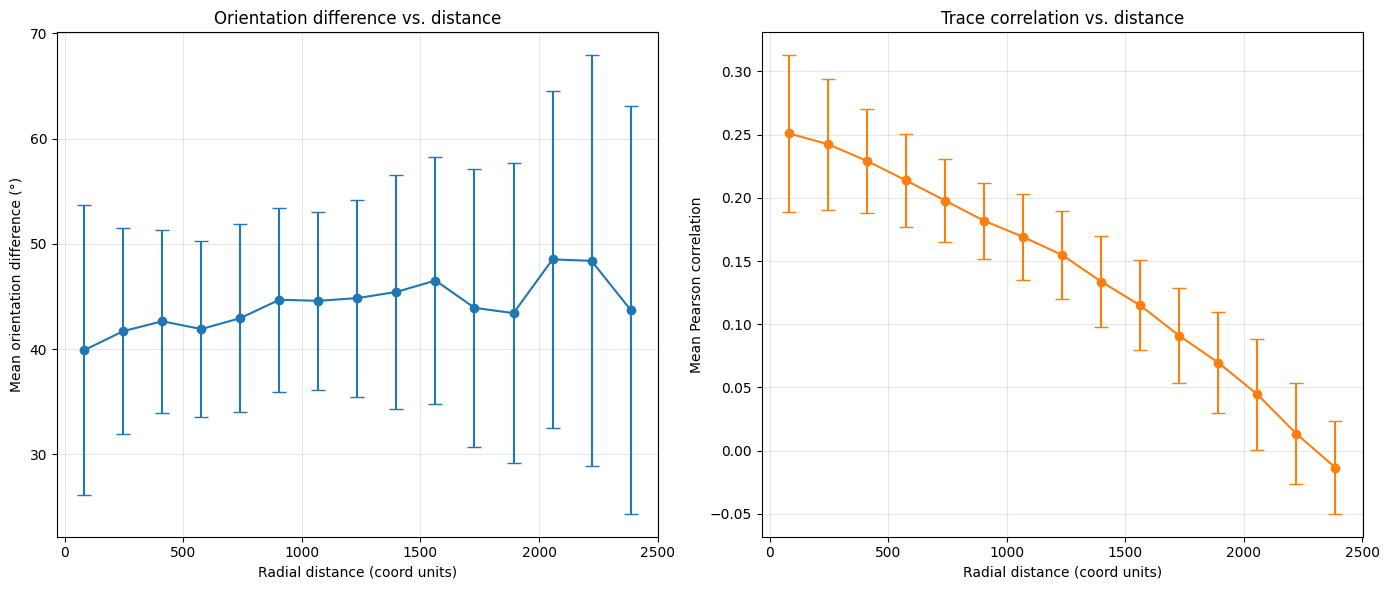

In [211]:
points = compute_radial_averages(pos, po_deg, traces_df)

In [84]:
ns = 10

X0 = X[:]
for i in range(X.shape[0]):

    mask = X0[i] > 0

    X0[i] -= X0[i].sum() / mask.sum()

    X0[i] *= mask

X0 = X0.view(X.shape[0], n,n)    

dim, comps = get_pca_dimensions(X0, n_samps=ns)
comps = comps.T.view(n,n,-1)
comps.shape, dim

measuring dimensionality, number of Nan found: 0


(torch.Size([64, 64, 4096]), 152)

In [16]:
plot_tensor_grid(comps, 5)

NameError: name 'comps' is not defined

Text(0.5, 1.0, 'Avg Power Spectrum')

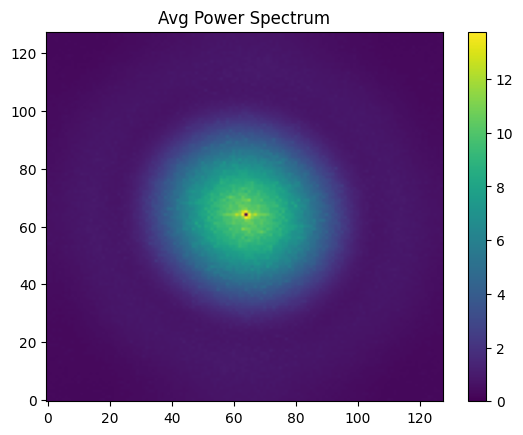

In [14]:
n = 128

# Compute 2D FFT along each row, shift zero-frequency to center
fft_B = np.fft.fftshift(np.fft.fft2(torch.tensor(X).view(X.shape[0],n,n)), axes=(-2, -1))
fft_B = np.abs(fft_B).mean(axis=0)
fft_B[n//2, n//2] = 0

# Plot average power spectrum (magnitude squared)
plt.imshow(fft_B, aspect='auto', origin='lower'); plt.colorbar(); plt.title('Avg Power Spectrum')